In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

print("OpenCV version:", cv2.__version__)
print("Libraries imported successfully")

OpenCV version: 5.0.0
Libraries imported successfully


In [20]:
video_path = "sample1.mp4"  

cap = cv2.VideoCapture(video_path)

if cap.isOpened():
    print("Video opened successfully")
else:
    print("Error: Video could not be opened")

Video opened successfully


In [21]:
# Read two consecutive frames

ret, frame1 = cap.read()
ret, frame2 = cap.read()

if ret:
    # Convert frames to grayscale
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    print("Two consecutive frames read successfully")
    print("Frame 1 shape:", gray1.shape)
    print("Frame 2 shape:", gray2.shape)
else:
    print("Error: Could not read video frames")

Two consecutive frames read successfully
Frame 1 shape: (1080, 1920)
Frame 2 shape: (1080, 1920)


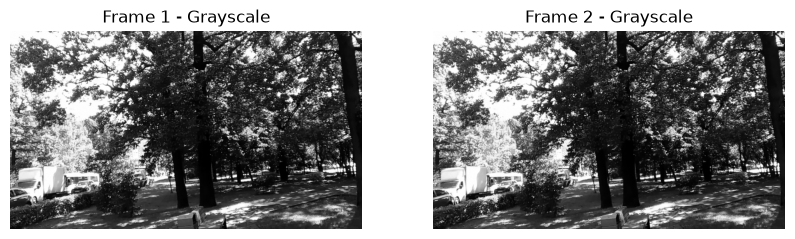

In [22]:
# to see grayscale frames
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray1, cmap="gray")
plt.title("Frame 1 - Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray2, cmap="gray")
plt.title("Frame 2 - Grayscale")
plt.axis("off")

plt.show()

In [23]:
# Detect good feature points in the first frame

feature_points = cv2.goodFeaturesToTrack(
    gray1,
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

# Calculate optical flow using Lucas-Kanade method

new_points, status, error = cv2.calcOpticalFlowPyrLK(
    gray1,
    gray2,
    feature_points,
    None
)

# Select only successfully tracked points

good_old = feature_points[status == 1]
good_new = new_points[status == 1]

print("Feature points detected:", len(feature_points))
print("Points successfully tracked:", len(good_new))

Feature points detected: 100
Points successfully tracked: 100


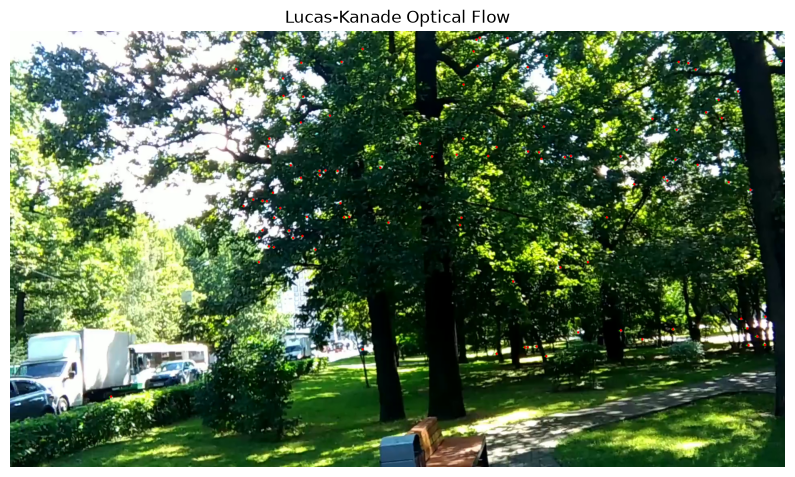

In [24]:
# Draw motion arrows on the second frame

output = frame2.copy()

for old, new in zip(good_old, good_new):
    x1, y1 = old.ravel()
    x2, y2 = new.ravel()

    cv2.arrowedLine(
        output,
        (int(x1), int(y1)),
        (int(x2), int(y2)),
        (0, 255, 0),
        2
    )

    cv2.circle(
        output,
        (int(x2), int(y2)),
        3,
        (0, 0, 255),
        -1
    )

# Convert BGR to RGB for matplotlib
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(output_rgb)
plt.title("Lucas-Kanade Optical Flow")
plt.axis("off")
plt.show()


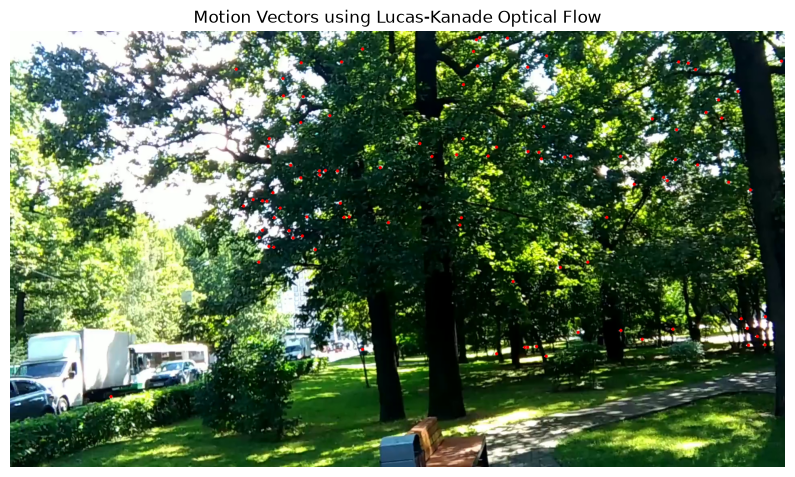

In [25]:
# Copy second frame for visualization
# /Ques 4
motion_frame = frame2.copy()

# Draw motion vectors
for old, new in zip(good_old, good_new):
    x1, y1 = old.ravel()
    x2, y2 = new.ravel()

    # Draw arrow
    cv2.arrowedLine(
        motion_frame,
        (int(x1), int(y1)),
        (int(x2), int(y2)),
        (255, 255, 255),
        2,
        tipLength=0.3
    )

    # Mark current position
    cv2.circle(
        motion_frame,
        (int(x2), int(y2)),
        4,
        (0, 0, 255),
        -1
    )

# Convert BGR to RGB for matplotlib
motion_rgb = cv2.cvtColor(motion_frame, cv2.COLOR_BGR2RGB)

# Display result
plt.figure(figsize=(10, 6))
plt.imshow(motion_rgb)
plt.title("Motion Vectors using Lucas-Kanade Optical Flow")
plt.axis("off")
plt.show()

In [26]:
# Convert frames to grayscale
# Ques 5 
gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

# Calculate Farneback Dense Optical Flow
flow = cv2.calcOpticalFlowFarneback(
    gray1,
    gray2,
    None,
    0.5,    # pyramid scale
    3,      # pyramid levels
    15,     # window size
    3,      # iterations
    5,      # polynomial neighborhood
    1.2,    # polynomial sigma
    0       # flags
)

print("Farneback Dense Optical Flow calculated successfully")
print("Flow shape:", flow.shape)

Farneback Dense Optical Flow calculated successfully
Flow shape: (1080, 1920, 2)


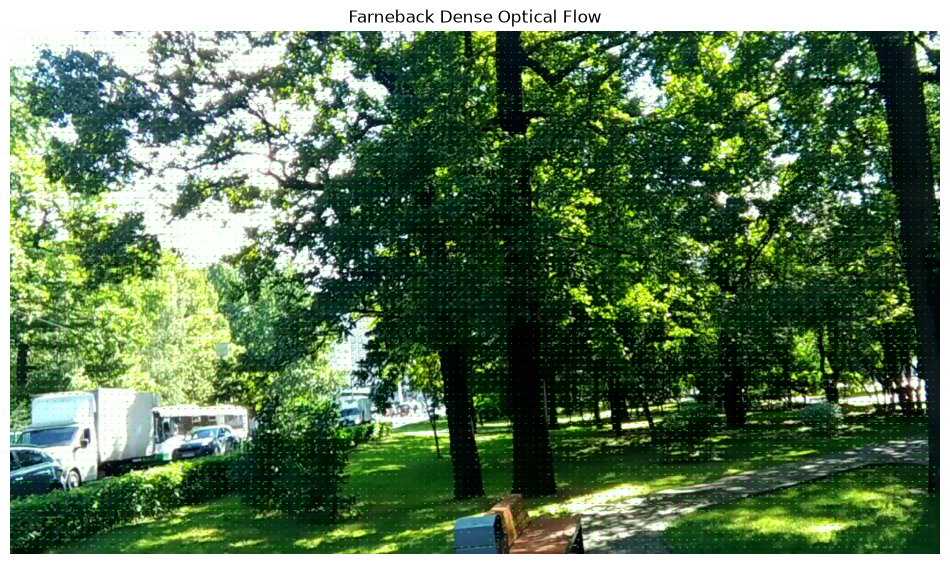

In [27]:
# Create a copy of the second frame
dense_frame = frame2.copy()

# Draw motion vectors
step = 15

for y in range(0, gray2.shape[0], step):
    for x in range(0, gray2.shape[1], step):

        fx, fy = flow[y, x]

        cv2.arrowedLine(
            dense_frame,
            (x, y),
            (int(x + fx), int(y + fy)),
            (0, 255, 0),
            1,
            tipLength=0.3
        )

# Convert BGR to RGB
dense_rgb = cv2.cvtColor(dense_frame, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(12, 7))
plt.imshow(dense_rgb)
plt.title("Farneback Dense Optical Flow")
plt.axis("off")
plt.show()

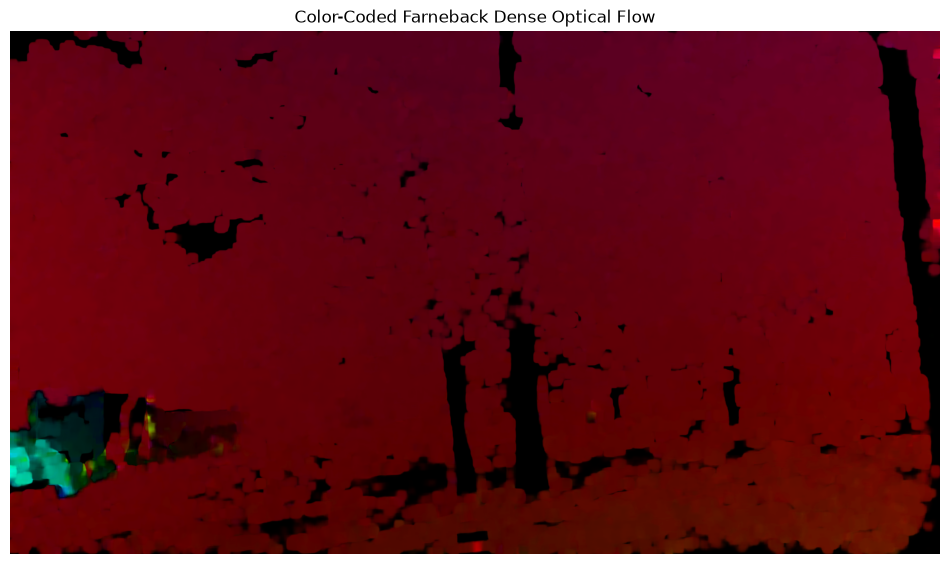

In [28]:
# ques 7
# Calculate magnitude and angle of the optical flow
magnitude, angle = cv2.cartToPolar(
    flow[..., 0],
    flow[..., 1]
)

# Create HSV image
hsv = np.zeros_like(frame2)

# Set saturation to maximum
hsv[..., 1] = 255

# Direction -> Hue
hsv[..., 0] = angle * 180 / np.pi / 2

# Magnitude -> Value
hsv[..., 2] = cv2.normalize(
    magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

# Convert HSV to BGR
flow_color = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

# Convert BGR to RGB for matplotlib
flow_rgb = cv2.cvtColor(flow_color, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(12, 7))
plt.imshow(flow_rgb)
plt.title("Color-Coded Farneback Dense Optical Flow")
plt.axis("off")
plt.show()

In [29]:
# ques 7
# ---------- Lucas-Kanade ----------
start_lk = time.time()

feature_points = cv2.goodFeaturesToTrack(
    gray1,
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

new_points, status, error = cv2.calcOpticalFlowPyrLK(
    gray1,
    gray2,
    feature_points,
    None
)

good_old = feature_points[status == 1]
good_new = new_points[status == 1]

lk_time = time.time() - start_lk


# ---------- Farneback ----------
start_fb = time.time()

flow = cv2.calcOpticalFlowFarneback(
    gray1,
    gray2,
    None,
    0.5,
    3,
    15,
    3,
    5,
    1.2,
    0
)

fb_time = time.time() - start_fb


# ---------- Comparison ----------
print("Lucas-Kanade Optical Flow")
print("Tracked points:", len(good_new))
print("Execution time:", round(lk_time, 5), "seconds")

print("\nFarneback Dense Optical Flow")
print("Flow shape:", flow.shape)
print("Execution time:", round(fb_time, 5), "seconds")

print("\nPerformance Comparison:")
if lk_time < fb_time:
    print("Lucas-Kanade is faster for this video frame.")
else:
    print("Farneback is faster for this video frame.")

Lucas-Kanade Optical Flow
Tracked points: 100
Execution time: 0.09461 seconds

Farneback Dense Optical Flow
Flow shape: (1080, 1920, 2)
Execution time: 1.23595 seconds

Performance Comparison:
Lucas-Kanade is faster for this video frame.


Average Motion Magnitude: 4.1856
Maximum Motion Magnitude: 11.8874


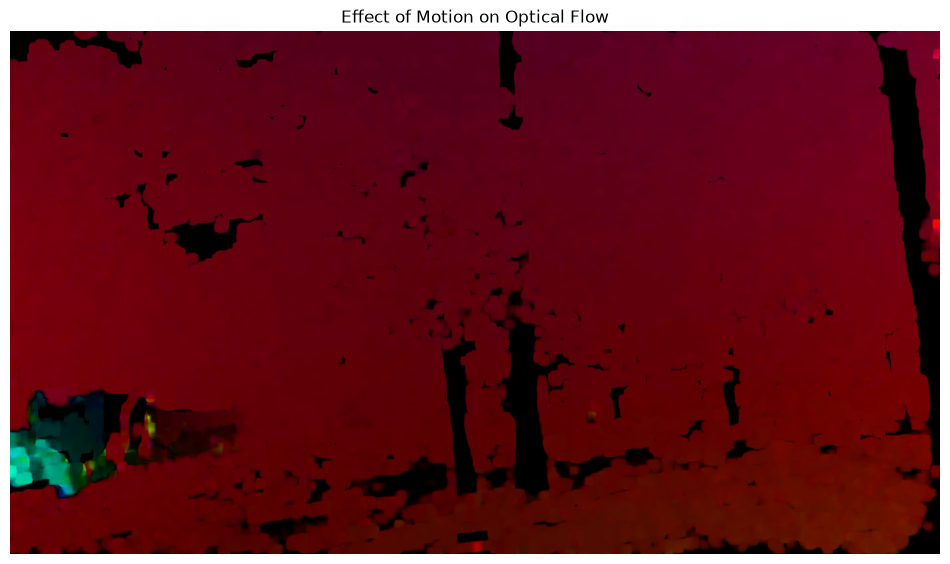

In [30]:
# ques 8
# Calculate Farneback optical flow
flow = cv2.calcOpticalFlowFarneback(
    gray1,
    gray2,
    None,
    0.5,
    3,
    15,
    3,
    5,
    1.2,
    0
)

# Calculate magnitude and direction
magnitude, angle = cv2.cartToPolar(
    flow[..., 0],
    flow[..., 1]
)

# Average motion magnitude
average_motion = np.mean(magnitude)
maximum_motion = np.max(magnitude)

print("Average Motion Magnitude:", round(average_motion, 4))
print("Maximum Motion Magnitude:", round(maximum_motion, 4))

# Color-coded optical flow
hsv = np.zeros_like(frame2)
hsv[..., 1] = 255

hsv[..., 0] = angle * 180 / np.pi / 2
hsv[..., 2] = cv2.normalize(
    magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

flow_color = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(flow_color)
plt.title("Effect of Motion on Optical Flow")
plt.axis("off")
plt.show()

In [31]:
# ques 9 
# Application suitability comparison

applications = [
    "Object Tracking",
    "Surveillance",
    "Autonomous Navigation"
]

lucas_kanade = [
    "Highly Suitable",
    "Suitable",
    "Suitable"
]

farneback = [
    "Suitable",
    "Highly Suitable",
    "Highly Suitable"
]

for i in range(len(applications)):
    print("\nApplication:", applications[i])
    print("Lucas-Kanade:", lucas_kanade[i])
    print("Farneback:", farneback[i])


Application: Object Tracking
Lucas-Kanade: Highly Suitable
Farneback: Suitable

Application: Surveillance
Lucas-Kanade: Suitable
Farneback: Highly Suitable

Application: Autonomous Navigation
Lucas-Kanade: Suitable
Farneback: Highly Suitable


In [32]:
# ques 10
# Final observations

print("Final Observations:")
print("1. Lucas-Kanade estimates motion of selected feature points.")
print("2. Farneback estimates dense motion across the image.")
print("3. Lucas-Kanade is generally computationally efficient.")
print("4. Farneback provides more complete motion information.")
print("5. Object speed and lighting conditions affect optical flow.")
print("6. Camera motion can influence the estimated motion.")
print("7. Optical flow is useful for dynamic scene analysis.")

Final Observations:
1. Lucas-Kanade estimates motion of selected feature points.
2. Farneback estimates dense motion across the image.
3. Lucas-Kanade is generally computationally efficient.
4. Farneback provides more complete motion information.
5. Object speed and lighting conditions affect optical flow.
6. Camera motion can influence the estimated motion.
7. Optical flow is useful for dynamic scene analysis.
